# 🎵 Music Genre Classification using CNN

This notebook trains a Convolutional Neural Network to classify music into 10 different genres using the GTZAN dataset.

**Genres:** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock

**Dataset:** GTZAN - 1000 audio tracks (100 per genre), 30 seconds each

---

## ⚡ Quick Start

1. **Run all cells sequentially** (Cell → Run All)
2. **Training time:** ~15-30 minutes
3. **Expected accuracy:** 75-85%

## 🔧 Memory Optimizations Applied

- ✅ Reduced batch size to 16
- ✅ Reduced model size (fewer filters)
- ✅ Mixed precision training enabled
- ✅ GPU memory growth configured

## 📊 What You'll Get

- Trained CNN model saved to `models/music_genre_cnn.h5`
- Label encoder saved to `models/label_encoder.npy`
- Training visualizations (accuracy, loss, confusion matrix)
- Per-genre accuracy breakdown

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

TensorFlow version: 2.20.0
GPU Available: []


In [2]:
## 2. Configure Dataset Path and Parameters

In [3]:
# Dataset path
DATA_PATH = r"C:\Users\admin\OneDrive\Desktop\SimpleDeepProject\Data\genres_original"
MODEL_SAVE_PATH = "models/music_genre_cnn.h5"
LABEL_ENCODER_PATH = "models/label_encoder.npy"

# Audio processing parameters
SAMPLE_RATE = 22050
DURATION = 30  # seconds
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

# Model parameters - REDUCED FOR MEMORY
EPOCHS = 50
BATCH_SIZE = 16  # Reduced from 32 to use less memory
LEARNING_RATE = 0.001

# Get genre list
GENRES = sorted(os.listdir(DATA_PATH))
print(f"Genres found: {GENRES}")
print(f"Number of genres: {len(GENRES)}")

Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of genres: 10


In [4]:
## 3. Feature Extraction - Mel Spectrogram

"""We'll convert audio signals into mel-spectrograms, which represent the frequency content of the audio over time. This is ideal for CNNs as it creates a 2D image-like representation."""

"We'll convert audio signals into mel-spectrograms, which represent the frequency content of the audio over time. This is ideal for CNNs as it creates a 2D image-like representation."

Mel-spectrogram shape: (128, 1293)


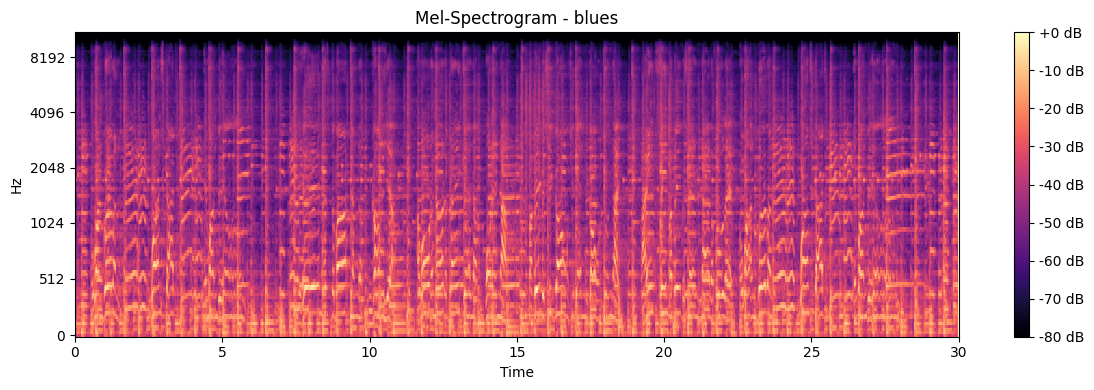

In [5]:
def extract_mel_spectrogram(audio_path, n_mels=128, max_pad_len=1293):
    """
    Extract mel-spectrogram from audio file
    
    Args:
        audio_path: Path to audio file
        n_mels: Number of mel bands
        max_pad_len: Maximum length to pad/truncate (for 30s audio)
    
    Returns:
        Mel-spectrogram as numpy array
    """
    try:
        # Load audio file
        audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)
        
        # Extract mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio, 
            sr=sr, 
            n_mels=n_mels,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Pad or truncate to fixed length
        if mel_spec_db.shape[1] < max_pad_len:
            pad_width = max_pad_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_pad_len]
        
        return mel_spec_db
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Test on one audio file
test_genre = GENRES[0]
test_files = os.listdir(os.path.join(DATA_PATH, test_genre))
test_audio = os.path.join(DATA_PATH, test_genre, test_files[0])

mel_spec = extract_mel_spectrogram(test_audio)
print(f"Mel-spectrogram shape: {mel_spec.shape}")

# Visualize
plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spectrogram - {test_genre}')
plt.tight_layout()
plt.show()

In [6]:
## 4. Load and Process Complete Dataset

"""This will take a few minutes to process all 1000 audio files."""

'This will take a few minutes to process all 1000 audio files.'

In [7]:
def load_dataset(data_path, genres):
    """
    Load all audio files and extract features
    
    Returns:
        X: Feature array (n_samples, n_mels, time_steps)
        y: Label array
    """
    features = []
    labels = []
    
    print("Loading dataset and extracting features...")
    
    for genre in genres:
        genre_path = os.path.join(data_path, genre)
        audio_files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
        
        print(f"\nProcessing {genre} ({len(audio_files)} files)...")
        
        for i, file in enumerate(audio_files):
            file_path = os.path.join(genre_path, file)
            mel_spec = extract_mel_spectrogram(file_path)
            
            if mel_spec is not None:
                features.append(mel_spec)
                labels.append(genre)
            
            if (i + 1) % 20 == 0:
                print(f"  Processed {i + 1}/{len(audio_files)} files")
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"Total samples: {len(features)}")
    
    return np.array(features), np.array(labels)

# Load the complete dataset
X, y = load_dataset(DATA_PATH, GENRES)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")

Loading dataset and extracting features...

Processing blues (100 files)...
  Processed 20/100 files
  Processed 20/100 files
  Processed 40/100 files
  Processed 40/100 files
  Processed 60/100 files
  Processed 60/100 files
  Processed 80/100 files
  Processed 80/100 files
  Processed 100/100 files

Processing classical (100 files)...
  Processed 100/100 files

Processing classical (100 files)...
  Processed 20/100 files
  Processed 20/100 files
  Processed 40/100 files
  Processed 40/100 files
  Processed 60/100 files
  Processed 60/100 files
  Processed 80/100 files
  Processed 80/100 files
  Processed 100/100 files

Processing country (100 files)...
  Processed 100/100 files

Processing country (100 files)...
  Processed 20/100 files
  Processed 20/100 files
  Processed 40/100 files
  Processed 40/100 files
  Processed 60/100 files
  Processed 60/100 files
  Processed 80/100 files
  Processed 80/100 files
  Processed 100/100 files

Processing disco (100 files)...
  Processed 100/1

In [8]:
## 5. Prepare Data for Training

"""Encode labels, reshape for CNN, and split into train/validation/test sets."""

'Encode labels, reshape for CNN, and split into train/validation/test sets.'

In [9]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=len(GENRES))

# Reshape for CNN: (samples, height, width, channels)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

# Normalize features to [0, 1]
X = (X - X.min()) / (X.max() - X.min())

# Split into train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_categorical, test_size=0.15, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 of 85% ≈ 15%
)

print(f"Training set: {X_train.shape} samples")
print(f"Validation set: {X_val.shape} samples")
print(f"Test set: {X_test.shape} samples")
print(f"\nInput shape for CNN: {X_train.shape[1:]}")
print(f"Number of classes: {len(GENRES)}")

# Save label encoder for later use
np.save(LABEL_ENCODER_PATH, label_encoder.classes_)
print(f"\n✓ Label encoder saved to {LABEL_ENCODER_PATH}")

Training set: (699, 128, 1293, 1) samples
Validation set: (150, 128, 1293, 1) samples
Test set: (150, 128, 1293, 1) samples

Input shape for CNN: (128, 1293, 1)
Number of classes: 10

✓ Label encoder saved to models/label_encoder.npy


In [10]:
## 6. Build CNN Model Architecture

"""Our CNN will have:
- **3 Convolutional Blocks**: Each with Conv2D → BatchNorm → ReLU → MaxPooling → Dropout
- **Dense Layers**: Flatten → Dense(256) → Dropout → Dense(128) → Output
- **Output**: 10 classes with softmax activation"""

'Our CNN will have:\n- **3 Convolutional Blocks**: Each with Conv2D → BatchNorm → ReLU → MaxPooling → Dropout\n- **Dense Layers**: Flatten → Dense(256) → Dropout → Dense(128) → Output\n- **Output**: 10 classes with softmax activation'

In [11]:
def build_cnn_model(input_shape, num_classes):
    """
    Build CNN model for music genre classification
    Memory-optimized version with fewer parameters
    """
    model = models.Sequential([
        # First Convolutional Block
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), padding='same'),  # Reduced from 32
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(32, (3, 3), padding='same'),  # Reduced from 64
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(64, (3, 3), padding='same'),  # Reduced from 128
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fourth Convolutional Block
        layers.Conv2D(128, (3, 3), padding='same'),  # Reduced from 256
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),  # Reduced from 256
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),  # Reduced from 128
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build model
model = build_cnn_model(input_shape=X_train.shape[1:], num_classes=len(GENRES))

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 1293, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1293, 16)  │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 1293, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 646, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 646, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 646, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 646, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 646, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 323, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 323, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 323, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 323, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 323, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 161, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 161, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 161, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 161, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 80, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 80, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 81920)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,485,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             

 Total params: 10,592,906 (40.41 MB)

 Trainable params: 10,592,426 (40.41 MB)

 Non-trainable params: 480 (1.88 KB)

In [ ]:
## 7. Memory Optimization & Training Setup

"""*Memory optimizations applied:**
- Reduced batch size to 16 (from 32)
- Reduced model filters by 50% 
- Mixed precision training enabled
- GPU memory growth configured"""

SyntaxError: can't use starred expression here (3466176783.py, line 3)

### Alternative: Use Smaller Dataset (If Still Out of Memory)

If you still get memory errors, uncomment and run this cell to use only 50% of the data:

In [ ]:
# ONLY RUN THIS IF YOU STILL GET MEMORY ERRORS
# This reduces dataset to 50% (500 samples instead of 1000)

# from sklearn.model_selection import train_test_split
# 
# # Take only 50% of data
# indices = np.arange(len(X))
# selected_indices, _ = train_test_split(
#     indices, train_size=0.5, random_state=42, stratify=y_encoded
# )
# 
# X = X[selected_indices]
# y_categorical = y_categorical[selected_indices]
# y_encoded = y_encoded[selected_indices]
# 
# # Re-split the data
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X, y_categorical, test_size=0.15, random_state=42, stratify=y_encoded[selected_indices]
# )
# 
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.176, random_state=42
# )
# 
# print(f"REDUCED - Training set: {X_train.shape} samples")
# print(f"REDUCED - Validation set: {X_val.shape} samples")
# print(f"REDUCED - Test set: {X_test.shape} samples")

In [ ]:
# Memory optimizations
import gc

# Clear any previous memory
gc.collect()
tf.keras.backend.clear_session()

# Configure GPU memory growth (if GPU available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU config error: {e}")

# Enable mixed precision for better memory efficiency
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✓ Mixed precision enabled")

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("\nStarting training with optimized settings...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(X_train)}")
print(f"Steps per epoch: {len(X_train) // BATCH_SIZE}\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training completed!")

Starting training...



Epoch 1/50


ResourceExhaustedError: Graph execution error:

Detected at node sequential_1/batch_normalization_1/moments/SquaredDifference defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 645, in run_forever

  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 1999, in

In [ ]:
## 8. Visualize Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best results
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\nBest Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f} at epoch {best_epoch + 1}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 9. Evaluate Model on Test Set

In [ ]:
# Load best model
best_model = keras.models.load_model(MODEL_SAVE_PATH)

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_classes, y_pred_classes, target_names=GENRES))

# Overall accuracy
print(f"\nOverall Test Accuracy: {accuracy_score(y_test_classes, y_pred_classes):.4f}")

## 10. Confusion Matrix Visualization

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=GENRES, yticklabels=GENRES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('True Genre', fontsize=12)
plt.title('Confusion Matrix - Music Genre Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Genre Accuracy:")
print("-" * 40)
for genre, acc in zip(GENRES, per_class_accuracy):
    print(f"{genre:15s}: {acc:.2%}")

## 11. Test Prediction on Sample Audio

In [ ]:
def predict_genre(audio_path, model, label_encoder_classes):
    """
    Predict genre for a given audio file
    """
    # Extract features
    mel_spec = extract_mel_spectrogram(audio_path)
    
    if mel_spec is None:
        return None, None
    
    # Reshape and normalize
    mel_spec = mel_spec.reshape(1, mel_spec.shape[0], mel_spec.shape[1], 1)
    mel_spec = (mel_spec - mel_spec.min()) / (mel_spec.max() - mel_spec.min())
    
    # Predict
    prediction = model.predict(mel_spec, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class]
    predicted_genre = label_encoder_classes[predicted_class]
    
    return predicted_genre, confidence, prediction[0]

# Test on a random sample from test set
sample_idx = np.random.randint(0, len(X_test))
sample_audio_path = None

# Find the corresponding audio file
count = 0
for genre in GENRES:
    genre_path = os.path.join(DATA_PATH, genre)
    audio_files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    if count + len(audio_files) > sample_idx:
        file_idx = sample_idx - count
        sample_audio_path = os.path.join(genre_path, audio_files[file_idx])
        true_genre = genre
        break
    count += len(audio_files)

if sample_audio_path:
    predicted_genre, confidence, all_probs = predict_genre(
        sample_audio_path, best_model, label_encoder.classes_
    )
    
    print(f"Audio File: {os.path.basename(sample_audio_path)}")
    print(f"True Genre: {true_genre}")
    print(f"Predicted Genre: {predicted_genre}")
    print(f"Confidence: {confidence:.2%}")
    print(f"\nAll Genre Probabilities:")
    print("-" * 40)
    
    # Sort by probability
    sorted_indices = np.argsort(all_probs)[::-1]
    for idx in sorted_indices:
        genre_name = label_encoder.classes_[idx]
        prob = all_probs[idx]
        bar = "█" * int(prob * 50)
        print(f"{genre_name:15s}: {prob:6.2%} {bar}")
    
    # Visualize the mel-spectrogram
    mel_spec = extract_mel_spectrogram(sample_audio_path)
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mel_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, 
                            x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram - True: {true_genre} | Predicted: {predicted_genre}')
    plt.tight_layout()
    plt.show()